In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection  import TimeSeriesSplit
from sklearn.linear_model     import LogisticRegression
from sklearn.preprocessing    import StandardScaler
from sklearn.feature_selection import mutual_info_classif


In [2]:
# =============== Load Datasets ===============

def load_data(path='../data/raw/IEEE-CIS Fraud Detection/'):
    train_trans = pd.read_csv(f'{path}train_transaction.csv')
    train_ident = pd.read_csv(f'{path}train_identity.csv')
    test_trans  = pd.read_csv(f'{path}test_transaction.csv')
    test_ident  = pd.read_csv(f'{path}test_identity.csv')
    
    # Fix columns names in Test Dataset
    test_ident.columns = test_ident.columns.str.replace("-", "_")

    train = train_trans.merge(train_ident, on='TransactionID', how='left')
    test  = test_trans.merge(test_ident,  on='TransactionID', how='left')
    
    return train, test

train, test = load_data()

In [3]:
pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [train.shape[0], test.shape[0]],
    "cols": [train.shape[1], test.shape[1]],
    "missing_%": [
        train.isnull().mean().mean() * 100,
        test.isnull().mean().mean() * 100
    ],
    "duplicates_%": [
        train.duplicated().mean() * 100,
        test.duplicated().mean() * 100
    ],
}).round(2)


,dataset,rows,cols,missing_%,duplicates_%
0,train,590540,434,45.07,0.0
1,test,506691,433,41.11,0.0


In [4]:
CAT_COLS = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 
                'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 
                'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 
                'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12',
                'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 
                'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 
                'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 
                'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 
                'id_37', 'id_38',]

def optimize_dtypes(df: pd.DataFrame, cat_cols) -> pd.DataFrame:
    """ Sets the correct data types for the dataset. """
    # Categorical Features: ProductCD card1 - card6 addr1, addr2 P_emaildomain R_emaildomain M1 - M9
    # Categorical Features: DeviceType DeviceInfo id_12 - id_38
    df = df.copy()
    existing_cat = [col for col in cat_cols if col in df.columns]
    df[existing_cat] = df[existing_cat].astype("category")
    exclude = {"isFraud", "TransactionID", "TransactionDT"} | set(existing_cat)
    float_cols = [
        c for c in df.select_dtypes(include=["float64", "int64", "int32"]).columns
        if c not in exclude
    ]
    df[float_cols] = df[float_cols].astype("float32")
    if "isFraud" in df.columns:
        df["isFraud"] = df["isFraud"].astype("int8")
    if "TransactionID" in df.columns:
        df["TransactionID"] = df["TransactionID"].astype("int32")
    if "TransactionDT" in df.columns:
        df["TransactionDT"] = df["TransactionDT"].astype("int32")

    return df

train = optimize_dtypes(train, CAT_COLS)
test = optimize_dtypes(test, CAT_COLS)
NUM_COLS = train.select_dtypes(include=['number']).columns


##### **Categorical Features**

In [5]:
train_desc = train[CAT_COLS].describe().T.add_prefix("train_")
test_desc  = test[CAT_COLS].describe().T.add_prefix("test_")

comparison = train_desc.join(test_desc)

comparison

,train_count,train_unique,train_top,train_freq,test_count,test_unique,test_top,test_freq
ProductCD,590540,5,W,439670,506691,5,W,360987
card1,590540,13553,7919,14932,506691,13244,7919,13083
card2,581607.0,500.0,321.0,48935.0,498037.0,497.0,321.0,42796.0
card3,588975.0,114.0,150.0,521287.0,503689.0,115.0,150.0,435558.0
card4,588963,4,visa,384767,503605,4,visa,334882
card5,586281.0,119.0,226.0,296546.0,502144.0,102.0,226.0,256991.0
card6,588969,4,debit,439938,503684,3,debit,385021
addr1,524834.0,332.0,299.0,46335.0,441082.0,292.0,299.0,38710.0
addr2,524834.0,74.0,87.0,520481.0,441082.0,72.0,87.0,435934.0
P_emaildomain,496084,59,gmail.com,228355,437499,60,gmail.com,207448


In [6]:
# Features cardinality

def compare_cat(train, test, cols):
    train_stats = pd.DataFrame({
        "train_missing_%": train[cols].isnull().mean() * 100,
        "train_unique": train[cols].nunique()
    })
    test_stats = pd.DataFrame({
        "test_missing_%": test[cols].isnull().mean() * 100,
        "test_unique": test[cols].nunique()
    })
    
    df = train_stats.join(test_stats)
    df["unique_diff"] = df["train_unique"] - df["test_unique"]
    
    return df.sort_values("unique_diff", key=abs, ascending=False)

compare_cat(train, test, CAT_COLS)

,train_missing_%,train_unique,test_missing_%,test_unique,unique_diff
DeviceInfo,79.905510,1786,77.292472,2226,-440
card1,0.000000,13553,0.000000,13244,309
id_33,87.589494,260,86.052446,390,-130
id_21,99.126393,490,99.001561,443,47
id_20,76.418024,394,73.231615,436,-42
addr1,11.126427,332,12.948523,292,40
id_25,99.130965,341,99.005508,309,32
id_13,78.440072,54,74.286893,27,27
id_19,76.408372,522,73.177736,502,20
card5,0.721204,119,0.897391,102,17


In [8]:
# Number of transactions per entity

def transactions_per_entity(df, col):
    counts = df.groupby(col, observed=True).size()
    return pd.Series({
        "mean": counts.mean(),
        "median": counts.median(),
        "p95": counts.quantile(0.95),
        "max": counts.max(),
        "n_unique": counts.shape[0]
    })


rows = []

for col in CAT_COLS:
    if col not in train.columns:
        continue

    train_stats = transactions_per_entity(train, col)
    test_stats  = transactions_per_entity(test, col)
    train_vals = set(train[col].dropna().unique())
    test_vals  = set(test[col].dropna().unique())
    coverage   = len(test_vals & train_vals) / max(len(test_vals), 1) * 100

    row = pd.concat([
        train_stats.add_prefix("train_"),
        test_stats.add_prefix("test_"),
        pd.Series({"coverage_%": round(coverage, 1)}),
    ])

    row.name = col
    rows.append(row)

summary = pd.DataFrame(rows).round(2)

summary
summary.style.background_gradient(subset=["coverage_%"])

,train_mean,train_median,train_p95,train_max,train_n_unique,test_mean,test_median,test_p95,test_max,test_n_unique,coverage_%
ProductCD,118108.000000,37699.000000,365439.800000,439670.000000,5.000000,101338.200000,35647.000000,302642.800000,360987.000000,5.000000,100.000000
card1,43.570000,4.000000,107.000000,14932.000000,13553.000000,38.260000,4.000000,93.000000,13083.000000,13244.000000,73.300000
card2,1163.210000,176.000000,5117.550000,48935.000000,500.000000,1002.090000,157.000000,3934.400000,42796.000000,497.000000,99.800000
card3,5166.450000,10.000000,921.050000,521287.000000,114.000000,4379.900000,14.000000,905.100000,435558.000000,115.000000,83.500000
card4,147240.750000,98772.500000,355434.500000,384767.000000,4.000000,125901.250000,82925.000000,308375.050000,334882.000000,4.000000,100.000000
card5,4926.730000,13.000000,17224.200000,296546.000000,119.000000,4922.980000,21.500000,20114.250000,256991.000000,102.000000,81.400000
card6,147242.250000,74508.000000,396295.200000,439938.000000,4.000000,167894.670000,118662.000000,358385.100000,385021.000000,3.000000,100.000000
addr1,1580.830000,3.000000,8481.600000,46335.000000,332.000000,1510.550000,3.000000,8268.600000,38710.000000,292.000000,62.700000
addr2,7092.350000,3.500000,85.150000,520481.000000,74.000000,6126.140000,4.000000,54.400000,435934.000000,72.000000,73.600000
P_emaildomain,8408.200000,305.000000,37823.200000,228355.000000,59.000000,7291.650000,296.000000,34380.750000,207448.000000,60.000000,98.300000


In [ ]:
def fraud_signal(df, col, global_rate):
    rates = df.groupby(col, observed=True)["isFraud"].mean()
    
    high_fraud = (rates > global_rate * 2).sum()
    coverage = high_fraud / len(rates) if len(rates) > 0 else 0

    return pd.Series({
        "n_unique": len(rates),
        "max_rate": rates.max(),
        "high_fraud_count": high_fraud,
        "coverage": coverage
    })

rows = []
global_rate = train["isFraud"].mean()

for col in CAT_COLS:
    if col not in train.columns:
        continue

    tr = fraud_signal(train, col, global_rate)

    row = tr.add_prefix("train_")
    row.name = col
    rows.append(row)

summary = pd.DataFrame(rows)

summary["signal_strength"] = summary["train_coverage"].apply(
    lambda x: "strong" if x > 0.05 else "weak"
)

summary = summary.sort_values("train_coverage", ascending=False).round(4)

summary
summary.style.background_gradient(subset=["train_coverage"])

,train_n_unique,train_max_rate,train_high_fraud_count,train_coverage,signal_strength
id_15,3.000000,0.105100,2.000000,0.666700,strong
id_23,3.000000,0.137300,2.000000,0.666700,strong
id_31,130.000000,1.000000,67.000000,0.515400,strong
id_12,2.000000,0.081700,1.000000,0.500000,strong
id_38,2.000000,0.097800,1.000000,0.500000,strong
id_29,2.000000,0.104500,1.000000,0.500000,strong
id_37,2.000000,0.083300,1.000000,0.500000,strong
id_28,2.000000,0.102800,1.000000,0.500000,strong
id_27,2.000000,0.082600,1.000000,0.500000,strong
DeviceType,2.000000,0.101700,1.000000,0.500000,strong


In [ ]:
### Define TOP - User_IDs composition

def add_uid_aggregations(
    train_df: pd.DataFrame,
    test_df:  pd.DataFrame,
    uid_cols: list,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = train_df.copy().sort_values("TransactionDT").reset_index(drop=True)
    test_df  = test_df.copy().sort_values("TransactionDT").reset_index(drop=True)

    has_dt_prev = "dt_prev" in train_df.columns

    for uid in uid_cols:
        if uid not in train_df.columns:
            print(f"[SKIP] '{uid}' is missing in train")
            continue
        if uid not in test_df.columns:
            print(f"[SKIP] '{uid}' is missing in test")
            continue

        grp = train_df.groupby(uid, sort=False)

        train_df[f"{uid}_tx_count"] = grp.cumcount()

        train_df[f"{uid}_amt_mean"] = (
            grp["TransactionAmt"]
            .expanding()
            .mean()
            .reset_index(level=0, drop=True)
            .shift(1)          
            .fillna(0)
        )

        if has_dt_prev:
            if "dt_prev" not in test_df.columns:
                print(f"[WARN] 'dt_prev' is missing in test — time_diff_mean пропущено")
            else:
                train_df[f"{uid}_time_diff_mean"] = (
                    grp["dt_prev"]
                    .expanding()
                    .mean()
                    .reset_index(level=0, drop=True)
                    .shift(1)  
                    .fillna(0)
                )

        last_state = (
            train_df
            .groupby(uid, sort=False)
            .agg(
                tx_count   = (f"{uid}_tx_count",  "last"),
                amt_mean   = (f"{uid}_amt_mean",   "last"),
            )
        )

        test_df[f"{uid}_tx_count"] = (
            test_df[uid].map(last_state["tx_count"]).fillna(0)
        )
        test_df[f"{uid}_amt_mean"] = (
            test_df[uid].map(last_state["amt_mean"]).fillna(0)
        )

        if has_dt_prev and f"{uid}_time_diff_mean" in train_df.columns:
            last_state_td = (
                train_df
                .groupby(uid, sort=False)[f"{uid}_time_diff_mean"]
                .last()
            )
            test_df[f"{uid}_time_diff_mean"] = (
                test_df[uid].map(last_state_td).fillna(0)
            )

    return train_df, test_df


def create_uid_variants(df: pd.DataFrame) -> tuple:
    """
    Create UID combinations for IEEE-CIS dataset.
    """

    def make_uid(cols: list, name: str) -> bool:
        """Безпечне створення composite ID. Повертає True якщо успішно."""
        if not all(c in df.columns for c in cols):
            return False
        result = df[cols[0]].astype(str).fillna("none")
        for c in cols[1:]:
            result = result + "_" + df[c].astype(str).fillna("none")
        df[name] = result
        return True

    uid_cols = []

    variants = {
        "uid_card123":                       ["card1", "card2", "card3"],
        "uid_card1_addr1":                   ["card1", "addr1"],
        "uid_card1_addr1_card2":             ["card1", "addr1", "card2"],
        "uid_card1_addr1_card5":             ["card1", "addr1", "card5"],
        "uid_card1_email":                   ["card1", "P_emaildomain"],
        "uid_card1_addr1_email":             ["card1", "addr1", "P_emaildomain"],
        "uid_card1_addr1_card2_email":       ["card1", "addr1", "card2", "P_emaildomain"],
        "uid_card1_device_info":             ["card1", "DeviceInfo"],
        "uid_card1_device_type":             ["card1", "DeviceType"],
        "uid_card1_device_info_device_type": ["card1", "DeviceInfo", "DeviceType"],
        "uid_card1_addr1_device_info":       ["card1", "addr1", "DeviceInfo"],
        "uid_card1_addr1_device_type":       ["card1", "addr1", "DeviceType"],
        "uid_card1_addr1_card2_device_type": ["card1", "addr1", "card2", "DeviceType"],
        "uid_card1_card5_addr1":             ["card1", "card5", "addr1"],
        "uid_card1_addr1_card5_email":       ["card1", "addr1", "card5", "P_emaildomain"],
        "id_card1_id31":                     ["card1", "id_31"],
        "id_card1_addr1_id31":               ["card1", "addr1", "id_31"],

        "id_card1_id20":                     ["card1", "id_20"],
        "id_card1_addr1_id20":               ["card1", "addr1", "id_20"],
        "id_card1_addr1_id31_id20":          ["card1", "addr1", "id_31", "id_20"],
        "id_card1_addr1_email_id31":         ["card1", "addr1", "P_emaildomain", "id_31"],
        "id_card1_addr1_email_id20":         ["card1", "addr1", "P_emaildomain", "id_20"],
        "id_card1_addr1_id33":               ["card1", "addr1", "id_33"],
        "id_card1_id31_card2":               ["card1", "id_31", "card2"],
        "id_card1_addr1_id31_card5":         ["card1", "addr1", "id_31", "card5"],
    }

    for name, cols in variants.items():
        if make_uid(cols, name):
            uid_cols.append(name)
    return df, uid_cols


def validate_uid_with_aggregations(
    df: pd.DataFrame,
    uid_cols: list,
    base_features: list,
    n_splits: int = 5,
    alpha: float = 10.0,
) -> tuple:
    
    df = df.sort_values("TransactionDT").reset_index(drop=True)
    y = df["isFraud"].values
    global_fraud = float(df["isFraud"].mean())
    tss = TimeSeriesSplit(n_splits=n_splits)

    # Baseline 
    base_feats = [f for f in base_features if f in df.columns]
    base_oof = np.zeros(len(df))

    for tr_idx, vl_idx in tss.split(df):
        X_tr = df.iloc[tr_idx][base_feats].fillna(0).values
        X_vl = df.iloc[vl_idx][base_feats].fillna(0).values
        scaler = StandardScaler()
        lr = LogisticRegression(C=0.1, max_iter=500, solver="saga", random_state=42)
        lr.fit(scaler.fit_transform(X_tr), y[tr_idx])
        base_oof[vl_idx] = lr.predict_proba(scaler.transform(X_vl))[:, 1]

    baseline_auc = roc_auc_score(y, base_oof)

    results = []

    for uid_col in uid_cols:
        if uid_col not in df.columns:
            continue
        agg_cols = [f"{uid_col}_tx_count", f"{uid_col}_amt_mean"]
        if "dt_prev" in df.columns:
            agg_cols.append(f"{uid_col}_time_diff_mean")
        oof_aggs = {col: np.full(len(df), 0.0) for col in agg_cols}
        oof_te   = np.full(len(df), global_fraud, dtype=np.float32)

        for tr_idx, vl_idx in tss.split(df):
            train_fold = df.iloc[tr_idx].copy()
            train_with_aggs, _ = add_uid_aggregations(train_fold, df.iloc[vl_idx].copy(), [uid_col])
            last_agg = (
                train_with_aggs
                .groupby(uid_col)[[
                    f"{uid_col}_tx_count",
                    f"{uid_col}_amt_mean",
                ]]
                .last()  
            )
            if "dt_prev" in df.columns:
                last_agg[f"{uid_col}_time_diff_mean"] = (
                    train_with_aggs
                    .groupby(uid_col)[f"{uid_col}_time_diff_mean"]
                    .last()
                )

            val_fold = df.iloc[vl_idx]
            for col in agg_cols:
                if col in last_agg.columns:
                    oof_aggs[col][vl_idx] = (
                        val_fold[uid_col]
                        .map(last_agg[col])
                        .fillna(0)
                        .values
                    )

            stats  = train_fold.groupby(uid_col)["isFraud"].agg(["sum", "count"])
            te_map = (stats["sum"] + alpha * global_fraud) / (stats["count"] + alpha)
            oof_te[vl_idx] = (
                val_fold[uid_col].map(te_map).fillna(global_fraud).values
            )

        aug_oof = np.zeros(len(df))
        extra_features = np.column_stack(
            [oof_te] + [oof_aggs[c] for c in agg_cols]
        )

        for tr_idx, vl_idx in tss.split(df):
            X_tr = np.column_stack([
                df.iloc[tr_idx][base_feats].fillna(0).values,
                extra_features[tr_idx],
            ])
            X_vl = np.column_stack([
                df.iloc[vl_idx][base_feats].fillna(0).values,
                extra_features[vl_idx],
            ])
            scaler = StandardScaler()
            lr = LogisticRegression(C=0.1, max_iter=500, solver="saga", random_state=42)
            lr.fit(scaler.fit_transform(X_tr), y[tr_idx])
            aug_oof[vl_idx] = lr.predict_proba(scaler.transform(X_vl))[:, 1]

        aug_auc      = roc_auc_score(y, aug_oof)
        residual_auc = aug_auc - baseline_auc
        te_auc       = roc_auc_score(y, oof_te)

        results.append({
            "uid_variant":  uid_col,
            "te_auc":       round(te_auc, 4),
            "aug_auc":      round(aug_auc, 4),
            "residual_auc": round(residual_auc, 4),
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("residual_auc", ascending=False)
        .reset_index(drop=True)
    )
    return results_df, baseline_auc


def validate_uid_marginal(
    df:            pd.DataFrame,
    uid_cols:      list,
    base_features: list = None,
    n_splits:      int   = 5,
    alpha:         float = 10.0,
) -> tuple:

    if base_features is None:
        base_features = [
            "TransactionAmt",
            "dt_prev", "tx_velocity", "tx_count_1h", "amt_diff_mean",
        ]
    base_features = [f for f in base_features if f in df.columns]

    df           = df.sort_values("TransactionDT").reset_index(drop=True)
    y            = df["isFraud"].values
    global_fraud = float(df["isFraud"].mean())
    tss          = TimeSeriesSplit(n_splits=n_splits)

    print(f"Global fraud rate : {global_fraud:.4f} ({global_fraud*100:.1f}%)")
    print(f"Base features     : {base_features}")
    print(f"Splits            : TimeSeriesSplit(n={n_splits})\n")

    base_oof = np.zeros(len(df))

    for tr_idx, vl_idx in tss.split(df):
        X_tr = df.iloc[tr_idx][base_features].fillna(0).values
        X_vl = df.iloc[vl_idx][base_features].fillna(0).values
        y_tr = y[tr_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_vl   = scaler.transform(X_vl)

        lr = LogisticRegression(
            C=0.1, max_iter=500,
            solver="saga", n_jobs=-1, random_state=42,
        )
        lr.fit(X_tr, y_tr)
        base_oof[vl_idx] = lr.predict_proba(X_vl)[:, 1]

    baseline_auc = roc_auc_score(y, base_oof)
    print(f"Baseline AUC (base features only): {baseline_auc:.4f}\n")
    print(f"{'─'*75}")
    print(f"  {'UID':<30} {'te_auc':>7} {'aug_auc':>8} {'residual':>9} "
          f"{'conc_10x':>9} {'avg_tx':>7}")
    print(f"{'─'*75}")

    results = []

    for uid_col in uid_cols:
        if uid_col not in df.columns:
            continue

        oof_te = np.full(len(df), global_fraud, dtype=np.float32)

        for tr_idx, vl_idx in tss.split(df):
            fold_train = df.iloc[tr_idx]
            stats      = fold_train.groupby(uid_col)["isFraud"].agg(["sum", "count"])
            te_map     = (
                (stats["sum"] + alpha * global_fraud)
                / (stats["count"] + alpha)
            )
            oof_te[vl_idx] = (
                df.iloc[vl_idx][uid_col]
                .map(te_map)
                .fillna(global_fraud)
                .values
            )

        try:
            te_auc = roc_auc_score(y, oof_te)
        except Exception:
            te_auc = 0.5

        aug_oof = np.zeros(len(df))

        for tr_idx, vl_idx in tss.split(df):
            X_tr_base = df.iloc[tr_idx][base_features].fillna(0).values
            X_vl_base = df.iloc[vl_idx][base_features].fillna(0).values

            X_tr = np.column_stack([X_tr_base, oof_te[tr_idx]])
            X_vl = np.column_stack([X_vl_base, oof_te[vl_idx]])
            y_tr = y[tr_idx]

            scaler = StandardScaler()
            X_tr   = scaler.fit_transform(X_tr)
            X_vl   = scaler.transform(X_vl)

            lr = LogisticRegression(
                C=0.1, max_iter=500,
                solver="saga", n_jobs=-1, random_state=42,
            )
            lr.fit(X_tr, y_tr)
            aug_oof[vl_idx] = lr.predict_proba(X_vl)[:, 1]

        try:
            aug_auc      = roc_auc_score(y, aug_oof)
            residual_auc = aug_auc - baseline_auc
        except Exception:
            aug_auc = baseline_auc
            residual_auc = 0.0

        try:
            mi = float(mutual_info_classif(
                oof_te.reshape(-1, 1), y,
                discrete_features = False,
                random_state      = 42,
            )[0])
        except Exception:
            mi = 0.0

        fraud          = df.groupby(uid_col)["isFraud"].agg(["mean", "sum", "count"])
        avg_tx         = float(fraud["count"].mean())
        multi_tx_pct   = float((fraud["count"] > 1).mean())
        fraud_conc_10x = float((fraud["mean"] > global_fraud * 10).mean())
        fraud_conc_50pct = float((fraud["mean"] > 0.5).mean())

        fr_sorted = fraud["mean"].sort_values().values
        n_fr      = len(fr_sorted)
        gini      = float(
            (2 * np.arange(1, n_fr + 1) - n_fr - 1) @ fr_sorted
            / (n_fr * fr_sorted.sum() + 1e-8)
        )

        sparsity_score = float(1 / np.log(avg_tx + 1 + 1e-8))

        results.append({
            "uid_variant":     uid_col,
            "n_uids":          len(fraud),
            "avg_tx_per_uid":  round(avg_tx, 2),
            "multi_tx_pct":    round(multi_tx_pct, 4),
            "fraud_conc_10x":  round(fraud_conc_10x, 4),
            "fraud_conc_50pct":round(fraud_conc_50pct, 4),
            "gini":            round(gini, 4),
            "sparsity_score":  round(sparsity_score, 4),
            "te_auc":          round(te_auc, 4),
            "aug_auc":         round(aug_auc, 4),
            "residual_auc":    round(residual_auc, 4),
            "mutual_info":     round(mi, 6),
        })

        symbol = "↑" if residual_auc > 0 else "↓"
        print(f"  {uid_col:<30} {te_auc:>7.4f} {aug_auc:>8.4f} "
              f"{symbol}{abs(residual_auc):>8.4f} "
              f"{fraud_conc_10x:>9.3f} {avg_tx:>7.1f}")

    results_df = pd.DataFrame(results)

    res_norm = (
        results_df["residual_auc"]
        / (results_df["residual_auc"].abs().max() + 1e-8)
    ).clip(0)

    purity = (
        results_df["fraud_conc_10x"] / (results_df["fraud_conc_10x"].max() + 1e-8) +
        results_df["gini"]
    ) / 2

    mi_norm = (
        results_df["mutual_info"]
        / (results_df["mutual_info"].max() + 1e-8)
    )

    te_norm = (results_df["te_auc"] - 0.5).clip(0) * 2

    results_df["score"] = (
        0.50 * res_norm                    +   
        0.20 * purity                      +   
        0.15 * mi_norm                     +   
        0.10 * te_norm                     +   
        0.05 * results_df["multi_tx_pct"]      
    )

    results_df = results_df.sort_values(
        "residual_auc", ascending=False
    ).reset_index(drop=True)

    print(f"\n{'═'*75}")
    print(f"  Baseline AUC: {baseline_auc:.4f}")
    print(f"{'═'*75}")
    print(results_df[[
        "uid_variant", "residual_auc", "aug_auc",
        "te_auc", "mutual_info", "fraud_conc_10x", "avg_tx_per_uid",
    ]].to_string(index=False))

    best = results_df.iloc[0]
    print(f"\n🥇 BEST: {best['uid_variant']}  score={best['score']:.4f}")
    print(f"   residual_auc (marginal) : {best['residual_auc']:+.4f}  ")
    print(f"   aug_auc (base + UID)    : {best['aug_auc']:.4f}")
    print(f"   baseline_auc            : {baseline_auc:.4f}")
    print(f"   te_auc  (standalone)    : {best['te_auc']:.4f}")
    print(f"   mutual_info             : {best['mutual_info']:.4f}")
    print(f"   fraud_conc_10x          : {best['fraud_conc_10x']:.3f}")
    print(f"   avg_tx_per_uid          : {best['avg_tx_per_uid']:.1f}")

    return results_df, baseline_auc



train_df, uid_cols = create_uid_variants(train.copy())
tes_df, _ = create_uid_variants(test.copy())

results, baseline_auc = validate_uid_with_aggregations(
    df            = train_df,
    uid_cols      = uid_cols,
    base_features = [
        "TransactionAmt", "dt_prev", "tx_velocity", 
        "tx_count_1h", "amt_diff_mean",
    ],
    n_splits = 5,
    alpha    = 10.0,
)
top_uids = results[results["residual_auc"] > 0]["uid_variant"].tolist()
train_final, test_final = add_uid_aggregations(train_df, tes_df, top_uids)
results


,uid_variant,te_auc,aug_auc,residual_auc
0,id_card1_addr1_id33,0.7384,0.6940,0.1709
1,uid_card1_addr1_email,0.7276,0.6913,0.1682
2,uid_card1_addr1_card5_email,0.7256,0.6896,0.1665
3,uid_card1_addr1_card2_email,0.7263,0.6861,0.1630
4,uid_card1_addr1_device_type,0.7289,0.6858,0.1627
5,uid_card1_addr1,0.7253,0.6854,0.1624
6,uid_card1_card5_addr1,0.7229,0.6839,0.1608
7,uid_card1_addr1_card5,0.7229,0.6839,0.1608
8,uid_card1_device_type,0.7180,0.6826,0.1595
9,uid_card1_addr1_card2_device_type,0.7275,0.6819,0.1588


##### **Feature Analysis for HGNN**

In [9]:
def analyze_graph_candidates(
    train_df:        pd.DataFrame,
    test_df:         pd.DataFrame,
    exclude_cols:    list = None,
    high_card_ratio: float = 0.10,   
    null_drop_thr:   float = 0.98,    
) -> pd.DataFrame:

    system_cols = {"TransactionID", "isFraud", "TransactionDT"}
    if exclude_cols:
        system_cols.update(exclude_cols)

    behavioral_cols = {
        "id_01", "id_02", "id_05", "id_06", "id_10", "id_11",
        "TransactionAmt", "dt_prev", "tx_velocity",
        "tx_count_1h", "amt_diff_mean", "log_dt_prev", "is_burst",
    }

    is_identifier = {
        "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "P_emaildomain", "R_emaildomain",
        "DeviceInfo", "DeviceType", "ProductCD",
    } | {f"id_{i}" for i in range(1, 39)}

    candidate_cols = [c for c in train_df.columns if c not in system_cols]
    global_fraud   = train_df["isFraud"].mean()
    rows           = []

    for col in sorted(candidate_cols):
        null_train = train_df[col].isna().mean()
        null_test  = test_df[col].isna().mean() if col in test_df.columns else 1.0

        dtype      = str(train_df[col].dtype)
        is_numeric = pd.api.types.is_numeric_dtype(train_df[col])
        # is_cat     = dtype in ("object", "category")

        notna_train = train_df[col].dropna()
        cardinality = notna_train.nunique()
        n_notna     = len(notna_train)
        density     = n_notna     / max(len(train_df), 1)
        reuse_ratio = 1 - cardinality / max(n_notna, 1)

        # Fraud signal
        try:
            fraud_by_group  = train_df.groupby(col)["isFraud"].mean()
            fraud_std       = float(fraud_by_group.std())
            fraud_lift_max  = float(fraud_by_group.max()) / max(global_fraud, 1e-8)
        except Exception:
            fraud_std      = 0.0
            fraud_lift_max = 1.0
            print("!!! EXCEPTION !!!")

        # Train / Test overlap
        if col in test_df.columns and cardinality < 10_000:
            test_vals  = set(test_df[col].dropna().unique())
            train_vals = set(notna_train.unique())
            overlap    = len(test_vals & train_vals) / max(len(test_vals), 1)
        else:
            overlap = 0.0   

        # Role heuristic
        if null_train > null_drop_thr:
            role = "DROP"
        elif cardinality > len(train_df) * high_card_ratio:
            role = "DROP"          # unique per-transaction
        elif col in behavioral_cols:
            role = "FEATURE"       # behavioral edge feature
        elif cardinality <= 2:
            role = "EDGE"          # binary → edge attribute
        elif cardinality <= 8 and (not is_numeric or fraud_std > 0.05):
            role = "EDGE"          # low-cardinality, categorical
        elif col in is_identifier and overlap < 0.05:
            role = "FEATURE"
        elif col in is_identifier and reuse_ratio > 0.60 and fraud_std > 0.05:
            role = "NODE"          # categorical entity
        elif is_numeric and cardinality <= 30:
            role = "EDGE" if fraud_std > 0.05 else "WEAK"
        elif fraud_std > 0.02 or fraud_lift_max > 3.0:
            role = "FEATURE"
        else:
            role = "WEAK"

        score = (
            0.40 * reuse_ratio                    +
            0.35 * min(fraud_std * 10, 1.0)       +
            0.15 * overlap                        +
            0.10 * min(fraud_lift_max / 10, 1.0)
        ) * (0.0 if role == "DROP" else 1.0)

        rows.append({
            "col":            col,
            "dtype":          dtype,
            "null_train":     round(null_train,     3),
            "null_test":      round(null_test,      3),
            "cardinality":    cardinality,
            "density":        round(density,        3),
            "reuse_ratio":    round(reuse_ratio,    3),
            "fraud_std":      round(fraud_std,      4),
            "fraud_lift_max": round(fraud_lift_max, 1),
            "overlap":        round(overlap,        3),
            "role":           role,
            "score":          round(score,          4),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["role", "score"], ascending=[True, False])
        .reset_index(drop=True)
    )


def print_graph_analysis(df: pd.DataFrame) -> None:
    role_order = ["NODE", "EDGE", "FEATURE", "WEAK", "DROP"]
    role_emoji = {
        "NODE":    "🔵",
        "EDGE":    "🟢",
        "FEATURE": "🟡",
        "WEAK":    "🟠",
        "DROP":    "🔴",
    }

    width  = 112
    header = (
        f"  {'col':<14} {'dtype':<8} {'null_tr':>7} {'null_te':>7} {'card':>7} "
        f"{'density':>8} {'reuse':>6} {'fr_std':>7} {'lift':>7} "
        f"{'overlap':>8}  {'role':<8} {'score':>6}"
    )

    print(f"\n{'═' * width}")
    print(header)

    for role in role_order:
        subset = df[df["role"] == role]
        if subset.empty:
            continue
        print(f"{'─' * width}")
        emoji = role_emoji[role]
        for _, r in subset.iterrows():
            print(
                f"  {r['col']:<14} {r['dtype']:<8} "
                f"{r['null_train']:>6.0%} {r['null_test']:>7.0%} "
                f"{r['cardinality']:>7d} {r['density']:>7.0%} "
                f"{r['reuse_ratio']:>6.2f} {r['fraud_std']:>7.4f} "
                f"{r['fraud_lift_max']:>7.1f}x {r['overlap']:>7.0%}  "
                f"{emoji} {role:<6} {r['score']:>6.3f}"
            )

    print(f"{'═' * width}")
    print(f"\n  Roles:")
    for role in role_order:
        subset = df[df["role"] == role]
        cols   = subset["col"].tolist()
        emoji  = role_emoji[role]
        line   = ", ".join(cols) if cols else "—"
        print(f"  {emoji} {role:<8} ({len(cols):>3})  {line}")

    print(f"""
  Legend:
  🔵 NODE    — categorical identifier, reuse>0.6 + fraud_std>0.05      → graph node
  🟢 EDGE    — binary / low-cardinality                                → edge attribute
  🟡 FEATURE —                                                         → node/edge feature
  🟠 WEAK    — weak signal                                             → candidate to drop
  🔴 DROP    — >98% NaN or high cardinality > {df.shape[0] * 0.1:.0f}  → to drop
    """)


graph_analysis = analyze_graph_candidates(train, test)
print_graph_analysis(graph_analysis)

node_cols    = graph_analysis[graph_analysis["role"] == "NODE"]["col"].tolist()
edge_cols    = graph_analysis[graph_analysis["role"] == "EDGE"]["col"].tolist()
feature_cols = graph_analysis[graph_analysis["role"] == "FEATURE"]["col"].tolist()

print(f"\nNODE cols    ({len(node_cols)}):    {node_cols}")
print(f"EDGE cols    ({len(edge_cols)}):    {edge_cols}")
print(f"FEATURE cols ({len(feature_cols)}): {feature_cols}")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  col            dtype    null_tr null_te    card  density  reuse  fr_std    lift  overlap  role      score
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  R_emaildomain  category    77%     73%      60     23%   1.00  0.1347    27.2x    100%  🔵 NODE    1.000
  id_13          category    78%     74%      54     22%   1.00  0.3033    28.6x     96%  🔵 NODE    0.994
  id_19          category    76%     73%     522     24%   1.00  0.1420    28.6x     91%  🔵 NODE    0.985
  id_14          category    86%     86%      25     14%   1.00  0.2370    28.6x     89%  🔵 NODE    0.983
  card3          category     0%      1%     114    100%   1.00  0.2587    28.6x     84%  🔵 NODE    0.975
  card5          category     1%      1%     119     99%   1.00  0.1094    28.6x     81%  🔵 NODE    0.972
  id_17          category    

**Select Best UIDs:**
te-auc - how much UID is predictive:  0.73+
residual_auc = aug_auc - baseline ( UID) 
avg_tx_per_uid - stability: <5 - noise; 5-15 - optimal; 30+ too much
fraud_conc_10x - anomaly clasters

Baseline UID: id_card1_addr1_id33   # id33 - screen reslotion/ browser info
Experiments: uid_card1_addr1_device_type
             uid_card1_addr1_email
             uid_card1_addr1

#####  **Numerical Features**

In [10]:
## Skewed Data Analysis

def analyze_skewness(
    df: pd.DataFrame,
    exclude_cols: list = None,
    skew_threshold: float = 0.5,
) -> pd.DataFrame:
    exclude = set(exclude_cols or [])
    num_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in exclude
    ]

    rows = []
    for col in num_cols:
        series  = df[col].dropna()
        if len(series) < 2:
            continue

        skew    = float(series.skew())
        kurt    = float(series.kurtosis())
        null_pct = df[col].isna().mean()

        if abs(skew) < skew_threshold:
            label = "✅ normal"
        elif abs(skew) < 1.0:
            label = "🟡 moderate"
        elif abs(skew) < 2.0:
            label = "🟠 high"
        else:
            label = "🔴 severe"

        direction = "right ▶" if skew > 0 else "left ◀"

        rows.append({
            "col":       col,
            "skewness":  round(skew, 4),
            "abs_skew":  round(abs(skew), 4),
            "kurtosis":  round(kurt, 4),
            "direction": direction,
            "null_pct":  round(null_pct, 3),
            "label":     label,
        })

    result = (
        pd.DataFrame(rows)
        .sort_values("abs_skew", ascending=False)
        .reset_index(drop=True)
    )

    width = 80
    print(f"\n{'═' * width}")
    print(f"  {'col':<20} {'skewness':>10} {'kurtosis':>10} "
          f"{'direction':>10} {'null':>6}  {'label'}")
    print(f"{'─' * width}")

    for label_group in ["🔴 severe", "🟠 high", "🟡 moderate", "✅ normal"]:
        subset = result[result["label"] == label_group]
        if subset.empty:
            continue
        for _, r in subset.iterrows():
            print(
                f"  {r['col']:<20} {r['skewness']:>10.4f} {r['kurtosis']:>10.4f} "
                f"{r['direction']:>10} {r['null_pct']:>5.0%}  {r['label']}"
            )
        print(f"{'─' * width}")

    print(f"\n  Distribution by skewness:")
    for label_group in ["🔴 severe", "🟠 high", "🟡 moderate", "✅ normal"]:
        n = (result["label"] == label_group).sum()
        print(f"  {label_group:<15} : {n:>4} колонок")

    print(f"\n  Thresholds:")
    print(f"  ✅ normal   : |skew| < {skew_threshold}")
    print(f"  🟡 moderate : |skew| < 1.0")
    print(f"  🟠 high     : |skew| < 2.0")
    print(f"  🔴 severe   : |skew| ≥ 2.0")
    print(f"{'═' * width}\n")

    return result

skew_analysis = analyze_skewness(
    train[NUM_COLS],
    exclude_cols=["TransactionID", "isFraud", "TransactionDT"],
    skew_threshold=0.5,
)

severe_skew_cols   = skew_analysis[skew_analysis["label"] == "🔴 severe"]["col"].tolist()
high_skew_cols     = skew_analysis[skew_analysis["label"] == "🟠 high"]["col"].tolist()
moderate_skew_cols = skew_analysis[skew_analysis["label"] == "🟡 moderate"]["col"].tolist()


════════════════════════════════════════════════════════════════════════════════
  col                    skewness   kurtosis  direction   null  label
────────────────────────────────────────────────────────────────────────────────
  V305                   384.2262 147628.2500    right ▶    0%  🔴 severe
  V311                   323.8314 156542.4219    right ▶    0%  🔴 severe
  V129                   240.2743 102763.1328    right ▶    0%  🔴 severe
  V309                   224.8753 94325.7109    right ▶    0%  🔴 severe
  V206                   207.8816 54107.1016    right ▶   76%  🔴 severe
  V319                   181.8336 47649.8984    right ▶    0%  🔴 severe
  V269                   177.8389 42255.3789    right ▶   78%  🔴 severe
  V266                   175.9588 41661.6367    right ▶   78%  🔴 severe
  V334                   168.4728 34776.3359    right ▶   86%  🔴 severe
  V135                   144.8832 31814.5723    right ▶    0%  🔴 severe
  V1                    -135.3003 18304.2930

In [ ]:
# TODO --- for LIGHTGBM, XGBOOST


##### **Сovariate shift check between train and test**

In [12]:
train_adv = train.copy()
test_adv  = test.copy()

train_adv['is_test'] = 0
test_adv['is_test']  = 1

combined = pd.concat([train_adv, test_adv], axis=0, ignore_index=True)

drop_cols = ['TransactionID', 'isFraud', 'is_test', 'TransactionDT']
feature_cols = [c for c in combined.columns if c not in drop_cols]

X = combined[feature_cols].copy()
y = combined['is_test'].values

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype("category")

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',          
    enable_categorical=True,          
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

print("\n Adversarial Validation Results")
print(f"  ROC-AUC per fold : {np.round(scores, 4)}")
print(f"  Mean ROC-AUC     : {scores.mean():.4f} ± {scores.std():.4f}")
print()

auc = scores.mean()
if auc < 0.55:
    msg = "Train ≈ Test - similar distribution, no strong shift."
elif auc < 0.70:
    msg = "Moderate shift - train/test distribution deffer."
else:
    msg = "Strong shift — train and test distributions are substantially different"
print(msg)


model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(20)

print("\n Top-20 features separating train from test:")
print(top_features.to_string())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.1min finished



 Adversarial Validation Results
  ROC-AUC per fold : [0.9024 0.9028 0.9039 0.9027 0.9045]
  Mean ROC-AUC     : 0.9033 ± 0.0008

Strong shift — train and test distributions are substantially different

 Top-20 features separating train from test:
V1            0.161566
V6            0.114778
V8            0.104327
V9            0.066498
V324          0.033434
DeviceType    0.025099
id_31         0.021822
V32           0.018038
V94           0.017788
V79           0.015911
V75           0.015544
V327          0.015140
M9            0.013857
dist1         0.013450
D15           0.011914
V71           0.011051
V76           0.010314
id_13         0.009556
V53           0.007789
C12           0.007674


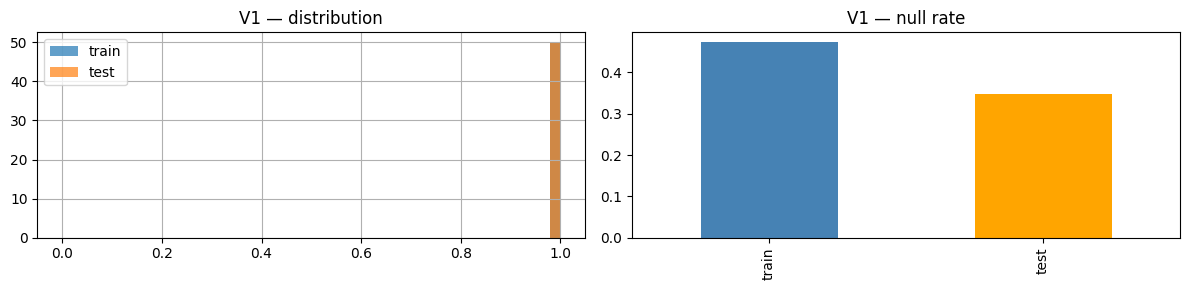

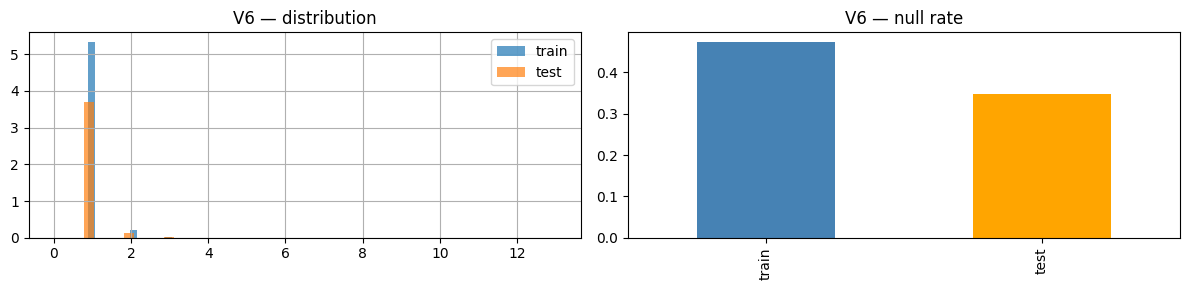

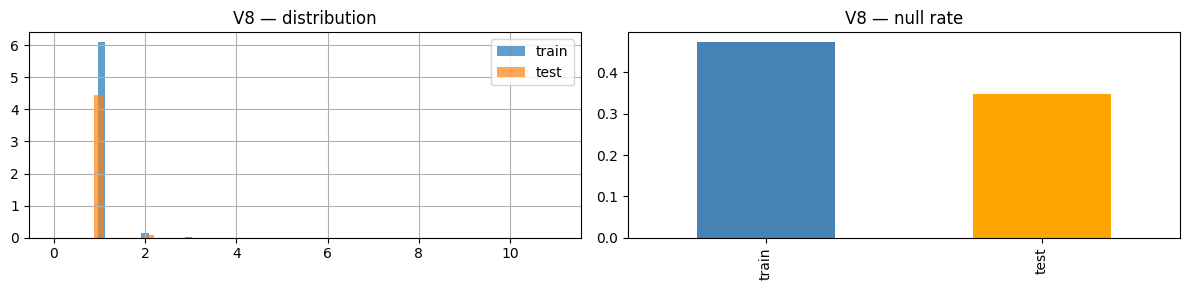

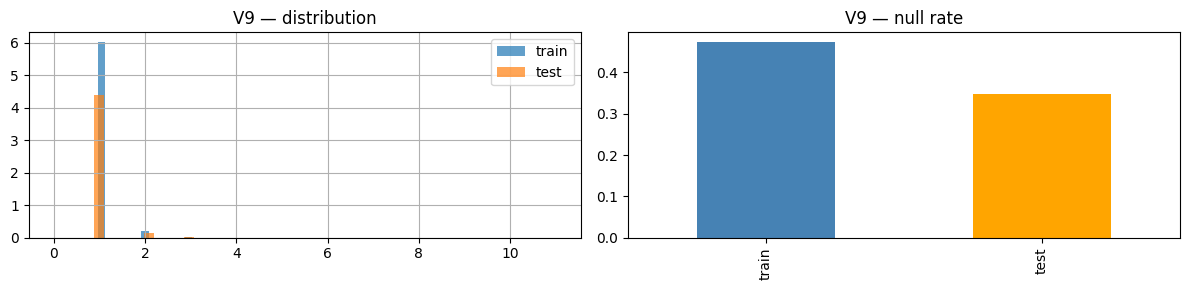

In [13]:
import matplotlib.pyplot as plt

for col in ['V1', 'V6', 'V8', 'V9']:
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    
    train[col].hist(bins=50, ax=ax[0], alpha=0.7, label='train', density=True)
    test[col].hist(bins=50, ax=ax[0], alpha=0.7, label='test', density=True)
    ax[0].set_title(f'{col} — distribution')
    ax[0].legend()
    
    # null rate
    null_rates = pd.Series({
        'train': train[col].isna().mean(),
        'test':  test[col].isna().mean()
    })
    null_rates.plot(kind='bar', ax=ax[1], color=['steelblue','orange'])
    ax[1].set_title(f'{col} — null rate')
    plt.tight_layout()
    plt.show()

##### 

In [14]:
# Features with >90% missing values            # TODO >99% create  binary feature: is_missing
 
missing = train.isnull().mean().sort_values(ascending=False)
drop_cols = missing[missing > 0.9].index
train = train.drop(columns=drop_cols)
print(f"Number of features with >90% missing values: {len(drop_cols)}")

Number of features with >90% missing values: 12


In [15]:
# Numeric features with low variance

from sklearn.feature_selection import VarianceThreshold

exclude = ['isFraud', 'TransactionID']
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop([col for col in exclude if col in numeric_cols])
X_numeric = train[numeric_cols]
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_numeric)

mask = selector.get_support()
drop_cols = X_numeric.columns[~mask]
train = train.drop(columns=drop_cols)
print(f"Number of features with low variance: {len(drop_cols)}")

Number of features with low variance: 24


In [16]:
# Correlation with the target (numeric features only)

numeric_train = train.select_dtypes(include=['number']).drop(columns=['TransactionID'])
correlations = numeric_train.corrwith(numeric_train['isFraud']).abs().sort_values(ascending=False)

print(correlations.head(10))   # Nothing to drop

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
dtype: float64


In [17]:
# Numeric features correlation

corr_matrix = numeric_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation > 0.95')
    .sort_values('correlation', ascending=False)
)

high_corr_pairs['target_corr_feature_1'] = high_corr_pairs['feature_1'].map(correlations)
high_corr_pairs['target_corr_feature_2'] = high_corr_pairs['feature_2'].map(correlations)

print(f"Number of high correlated feature pairs: {len(high_corr_pairs)}")
print(high_corr_pairs.to_string(index=False))

Number of high correlated feature pairs: 570
feature_1 feature_2  correlation  target_corr_feature_1  target_corr_feature_2
       D4       D12     0.999999               0.067216               0.028864
      V95      V322     0.999949               0.004120               0.021541
      V96      V323     0.999948               0.005484               0.023329
      V97      V324     0.999947               0.004491               0.024006
     V101      V322     0.999698               0.004712               0.021541
     V279      V322     0.999624               0.003751               0.021541
      V95      V101     0.999594               0.004120               0.004712
     V279      V293     0.999568               0.003751               0.004501
       C7       C12     0.999489               0.028160               0.031905
     V280      V324     0.999464               0.000782               0.024006
     V293      V322     0.999403               0.004501               0.021541
     V1

In [18]:
# High correlated numeric features

high_corr_pairs['to_drop'] = high_corr_pairs.apply(
    lambda row: row['feature_2'] if row['target_corr_feature_1'] >= row['target_corr_feature_2']
    else row['feature_1'], axis=1
)

cols_to_drop = high_corr_pairs['to_drop'].unique().tolist()
train = train.drop(columns=cols_to_drop)
print(f"Number of high-correlated numeric features: {len(cols_to_drop)}")

Number of high-correlated numeric features: 134


In [19]:
# Features with >95% unique values

exclude = [
    'TransactionID', 'isFraud',
    'TransactionDT', 'TransactionAmt',
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'dist1', 'dist2',
    'P_emaildomain', 'R_emaildomain'
]

unique_ratio = train.nunique() / len(train)
high_unique_cols = unique_ratio[unique_ratio >= 0.95].index.tolist()
high_unique_cols = [col for col in high_unique_cols if col not in exclude]

print(f"Number of columns with >95% unique values: {len(high_unique_cols)}")
train = train.drop(columns=high_unique_cols)

Number of columns with >95% unique values: 0


        median_time_diff_sec  mean_time_diff_sec
fraud                 5754.0            279421.0
normal                9090.0            250224.0


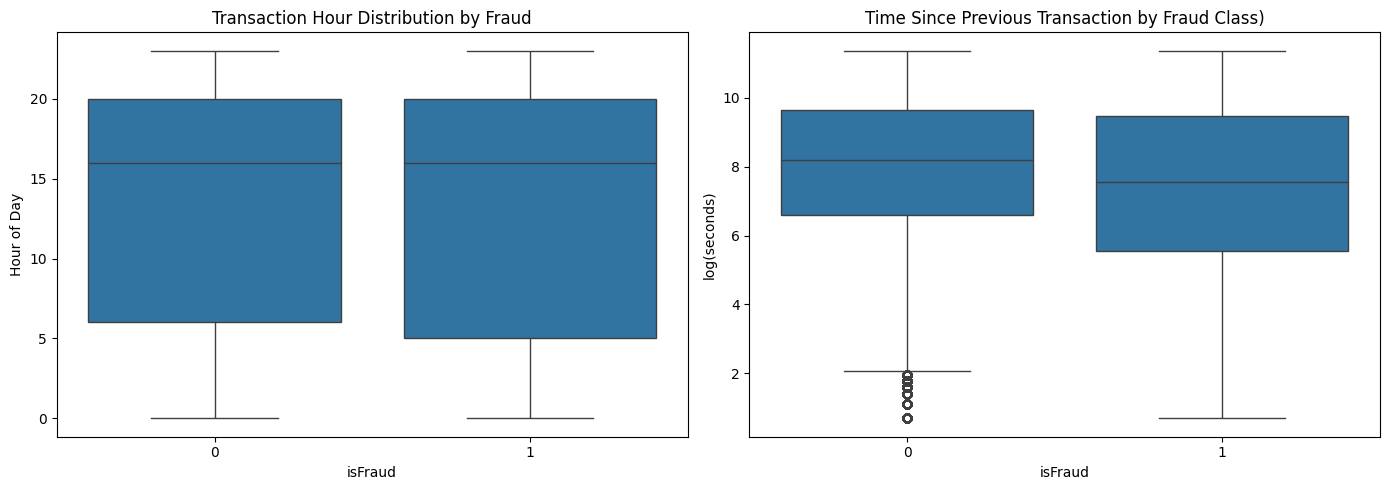

In [23]:
# Temporal Behaviour Analysis by Fraud

import matplotlib.pyplot as plt
import seaborn as sns

def add_time_features(df):
    df = df.copy()
    df = df.sort_values(["user_id", "TransactionDT"]).reset_index(drop=False)
    df["trans_hour"] = ((df["TransactionDT"] // 3600) % 24).astype("int8")
    df["time_diff"] = df.groupby("user_id")["TransactionDT"].diff()
    df = df.sort_values("index").drop(columns="index").reset_index(drop=True)
    return df

train_time = train.copy()

train_time["DeviceInfo"] = (
    train_time["DeviceInfo"]
    .astype("object")
    .where(train_time["DeviceInfo"].notna(), "unknown")
    .astype(str)
)

train_time["card1"] = (
    train_time["card1"]
    .astype("object")
    .where(train_time["card1"].notna(), "unknown")
    .astype(str)
)

train_time["user_id"] = (
    train_time["card1"].astype(str)
    + "_"
    + train_time["DeviceInfo"].astype(str)
)

train_time = add_time_features(train_time)

summary = pd.DataFrame({
    "median_time_diff_sec": [
        train_time.loc[train_time["isFraud"] == 1, "time_diff"].median(),
        train_time.loc[train_time["isFraud"] == 0, "time_diff"].median(),
    ],
    "mean_time_diff_sec": [
        train_time.loc[train_time["isFraud"] == 1, "time_diff"].mean(),
        train_time.loc[train_time["isFraud"] == 0, "time_diff"].mean(),
    ],
}, index=["fraud", "normal"]).round(0)

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Transaction hour
sns.boxplot(data=train_time, x="isFraud", y="trans_hour", ax=axes[0])
axes[0].set_title("Transaction Hour Distribution by Fraud")
axes[0].set_xlabel("isFraud")
axes[0].set_ylabel("Hour of Day")

plot_df = train_time[
    train_time["time_diff"].notna()
    & (train_time["time_diff"] > 0)
    & (train_time["time_diff"] < 86400)
].copy()
plot_df["log_time_diff"] = np.log1p(plot_df["time_diff"])

sns.boxplot(data=plot_df, x="isFraud", y="log_time_diff", ax=axes[1])
axes[1].set_title("Time Since Previous Transaction by Fraud Class)")
axes[1].set_xlabel("isFraud")
axes[1].set_ylabel("log(seconds)")

plt.tight_layout()
plt.show()

In [26]:
train_time["is_fast_tx"] = train_time["time_diff"] < 60

fast_summary = train_time.groupby("isFraud")["is_fast_tx"].mean()

print("\n % of fast transactions (<60s)")
print(fast_summary)


 % of fast transactions (<60s)
isFraud
0    0.027560
1    0.054252
Name: is_fast_tx, dtype: float64


### **LightGBM importance:**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# Temporal Behavior Feature Importance with LightGBM

df = train_time.copy()
df = df.sort_values("TransactionDT").reset_index(drop=True)
df["time_diff"] = df["time_diff"].fillna(1e6)
df["log_time_diff"] = np.log1p(df["time_diff"]).astype("float32")
drop_cols = [
    "isFraud",
    "TransactionID",
    "TransactionDT",
    "user_id",
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["isFraud"]

cat_cols = [
    c for c in CAT_COLS
    if c in X.columns
]

for col in cat_cols:
    X[col] = (
        X[col]
        .astype("object")
        .where(X[col].notna(), "missing")
        .astype("category")
    )

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
for col in object_cols:
    X[col] = (
        X[col]
        .where(X[col].notna(), "missing")
        .astype("category")
    )
    cat_cols.append(col)

cat_cols = list(dict.fromkeys(cat_cols))

split_idx = int(len(train) * 0.8)
X_train = X.iloc[:split_idx].copy()
y_train = y.iloc[:split_idx].copy()
X_val = X.iloc[split_idx:].copy()
y_val = y.iloc[split_idx:].copy()

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

val_proba = model.predict_proba(X_val)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val, val_proba))
print("PR-AUC :", average_precision_score(y_val, val_proba))

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(70).to_string(index=False))

Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.475242	valid_0's binary_logloss: 0.319078
[200]	valid_0's average_precision: 0.520991	valid_0's binary_logloss: 0.249557
[300]	valid_0's average_precision: 0.53587	valid_0's binary_logloss: 0.217775
[400]	valid_0's average_precision: 0.540617	valid_0's binary_logloss: 0.198428
[500]	valid_0's average_precision: 0.542102	valid_0's binary_logloss: 0.184563
Early stopping, best iteration is:
[489]	valid_0's average_precision: 0.542546	valid_0's binary_logloss: 0.185677
ROC-AUC: 0.9035221894343447
PR-AUC : 0.5425463773258754
       feature  importance
         card1        5987
         card2        1442
         addr1        1058
    DeviceInfo         613
         id_19         411
         id_20         370
         id_31         296
            C2         296
 P_emaildomain         296
           C13         278
TransactionAmt         220
            D2         194
 R_emaildomain         1

<Figure size 1000x1200 with 0 Axes>

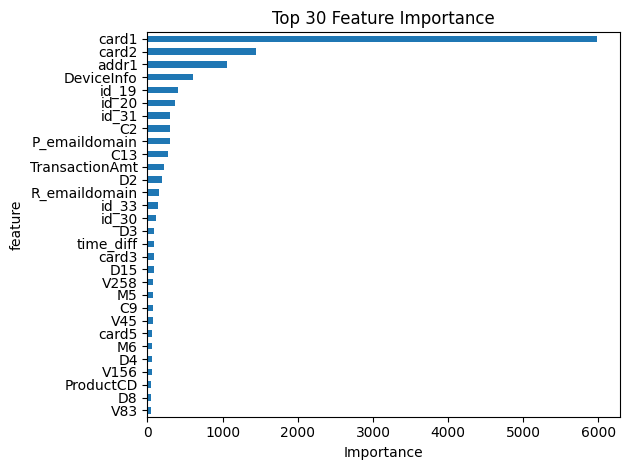

In [28]:
plt.figure(figsize=(10, 12))
importance.head(30).plot(kind='barh', x='feature', y='importance', legend=False)
plt.title('Top 30 Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Gain importance
importance_gain = pd.DataFrame({
    'feature': X.columns,
    'importance': model.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

importance_gain

,feature,importance
2,card1,2.880765e+06
186,V258,7.882868e+05
3,card2,7.605363e+05
12,R_emaildomain,3.638848e+05
17,C13,3.634584e+05
...,...,...
23,D9,0.000000e+00
238,id_10,0.000000e+00
240,id_12,0.000000e+00
263,is_fast_tx,0.000000e+00


In [32]:
top_features = importance_gain[importance_gain['importance'] > 0]['feature'].tolist()

print(f"Features with importance > 0: {len(top_features)}")
print(f"Features with importance = 0: {importance_gain[importance_gain['importance'] == 0].shape[0]}")


Features with importance > 0: 185
Features with importance = 0: 80


In [33]:
num_cols = train.select_dtypes(include=['float64']).columns
train[num_cols] = train[num_cols].astype('float32')

##### **Target**

In [ ]:
# Target

print(train['isFraud'].value_counts())
print(train['isFraud'].value_counts(normalize=True))

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [ ]:
# TransactionAMT: transaction payment amount in USD

print(train['TransactionAmt'].describe())
print(train.groupby('isFraud')['TransactionAmt'].describe())

count    590540.000000
mean        135.027176
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64
            count        mean         std    min        25%   50%    75%  \
isFraud                                                                    
0        569877.0  134.511658  239.395081  0.251  43.970001  68.5  120.0   
1         20663.0  149.244766  232.212158  0.292  35.043999  75.0  161.0   

                  max  
isFraud                
0        31937.390625  
1         5191.000000  


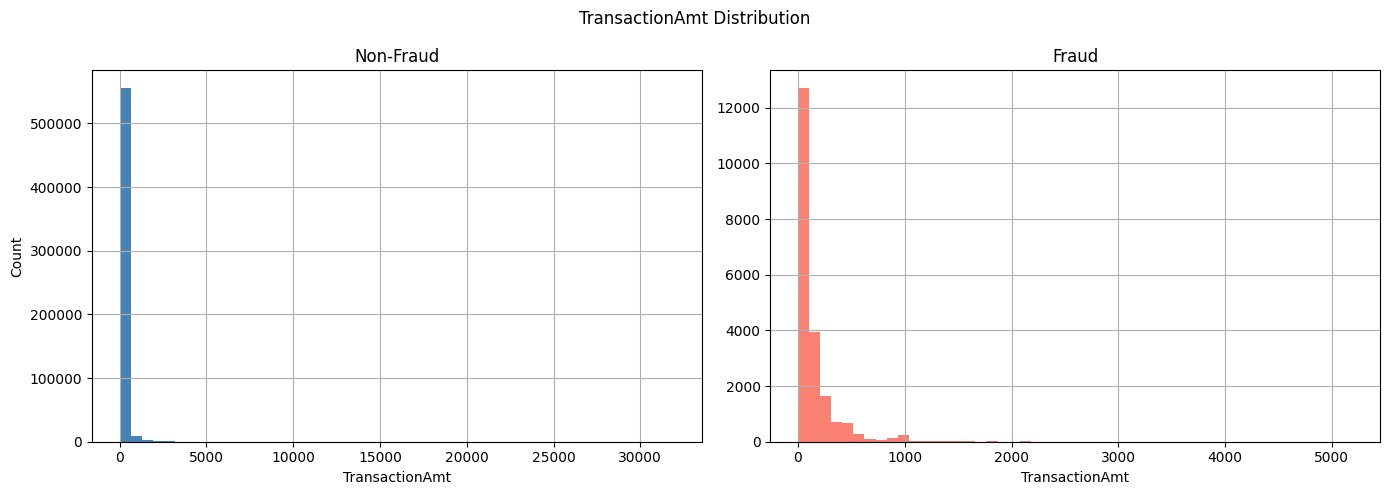

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train[train['isFraud'] == 0]['TransactionAmt'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Non-Fraud')
axes[0].set_xlabel('TransactionAmt')
axes[0].set_ylabel('Count')

train[train['isFraud'] == 1]['TransactionAmt'].hist(bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Fraud')
axes[1].set_xlabel('TransactionAmt')

plt.suptitle('TransactionAmt Distribution')
plt.tight_layout()
plt.show()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


isFraud
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: TransactionDT, dtype: object

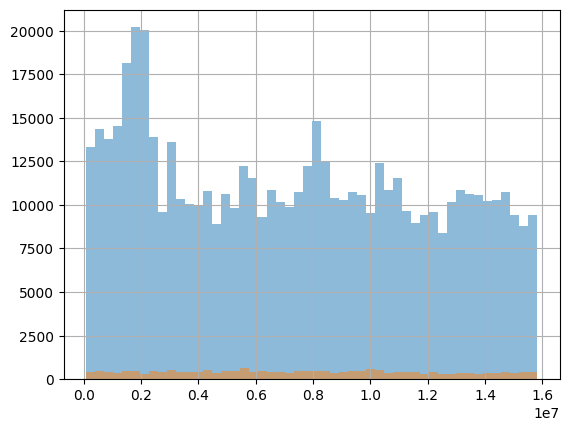

In [37]:
# Time Feature — TransactionDT

print(train['TransactionDT'].describe())

# Fraud by Time
train.groupby('isFraud')['TransactionDT'].hist(bins=50, alpha=0.5)

In [39]:
## Feature Cardinality

card_cols  = [f"card{i}" for i in range(1, 7)]          # усі card1..card6
other_cols = ["addr1", "addr2",
              "P_emaildomain", "R_emaildomain",
              "DeviceInfo", "DeviceType"]
entity_cols = card_cols + other_cols

print("Cardinality (train vs test)")
for col in entity_cols:
    tr = train[col].nunique() if col in train.columns else "N/A"
    te = test[col].nunique()  if col in test.columns  else "N/A"
    print(f"  {col:<20} train={tr:>6}  test={te:>6}")

Cardinality (train vs test)
  card1                train= 13553  test= 13244
  card2                train=   500  test=   497
  card3                train=   114  test=   115
  card4                train=     4  test=     4
  card5                train=   119  test=   102
  card6                train=     4  test=     3
  addr1                train=   332  test=   292
  addr2                train=    74  test=    72
  P_emaildomain        train=    59  test=    60
  R_emaildomain        train=    60  test=    60
  DeviceInfo           train=  1786  test=  2226
  DeviceType           train=     2  test=     2


User node degree statistics:
  Mean degree        : 40.59
  Median degree      : 4.00
  Max degree         : 14,891
  Fraud-related users: 1,800
  Avg degree of fraud-related users: 251.50


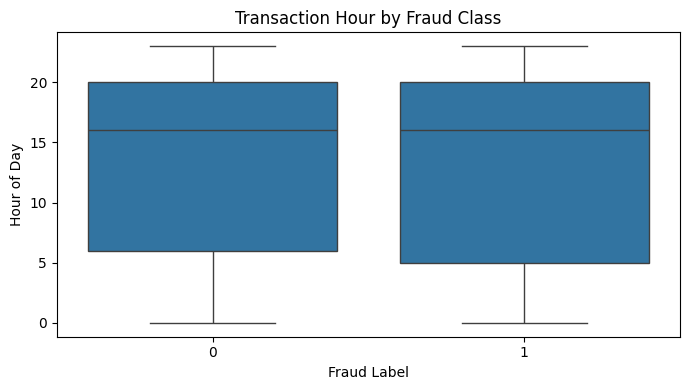


Device risk statistics:
  High-risk devices (>10% fraud, >=5 tx): 265
  Total devices                         : 1,787


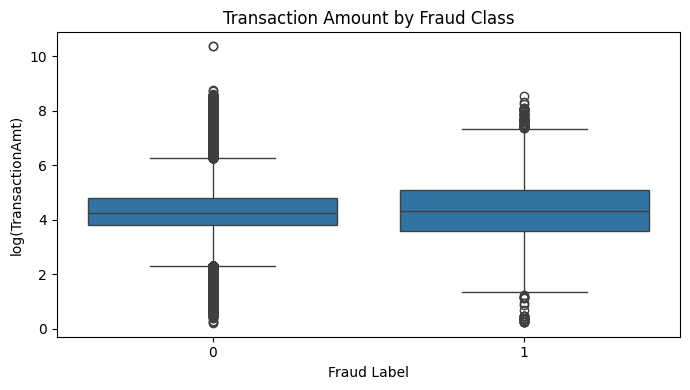


Edge candidate statistics:
  User → Transaction: one-to-many relation
  Avg transactions per device: 330.46

Address fraud-rate distribution:
count    332.000000
mean       0.025291
std        0.083744
min        0.000000
25%        0.000000
50%        0.000000
75%        0.010905
max        0.666667
Name: isFraud, dtype: float64


In [42]:
# # Edges discovery
# - ('user', 'makes', 'transaction'): card-based
# - ('transaction', 'uses', 'device'): DeviceInfo
# - ('transaction', 'from', 'address'): addr1/addr2
# - ('transaction', 'to', 'merchant'): V-features patterns
# - ('user', 'has_email', 'email'): emaildomain

def as_str_unknown(s):
    return (
        s.astype("object")
         .where(s.notna(), "unknown")
         .astype(str)
         .replace("nan", "unknown")
    )

train_g = train.copy()
train_g["card1_str"] = as_str_unknown(train_g["card1"])
train_g["card2_str"] = as_str_unknown(train_g["card2"])
train_g["card3_str"] = as_str_unknown(train_g["card3"])
train_g["user_id"] = (
    train_g["card1_str"] + "_"
    + train_g["card2_str"] + "_"
    + train_g["card3_str"]
)

user_deg = train_g.groupby('user_id')['TransactionID'].count()
user_fraud = train_g[train_g.isFraud == 1].groupby('user_id')['TransactionID'].count()

user_stats = user_deg.to_frame('degree').join(user_fraud.rename('fraud_degree'), how='left').fillna(0)

print("User node degree statistics:")
print(f"  Mean degree        : {user_stats['degree'].mean():.2f}")
print(f"  Median degree      : {user_stats['degree'].median():.2f}")
print(f"  Max degree         : {user_stats['degree'].max():,.0f}")
print(f"  Fraud-related users: {(user_stats['fraud_degree'] > 0).sum():,}")
print(
    f"  Avg degree of fraud-related users: "
    f"{user_stats.loc[user_stats['fraud_degree'] > 0, 'degree'].mean():.2f}"
)

# 2. Temporal analysis
train_g['trans_hour'] = ((train_g['TransactionDT'] // 3600) % 24).astype("int8")  # 24h cycle
plt.figure(figsize=(7, 4))
sns.boxplot(data=train_g, x="isFraud", y="trans_hour")
plt.title("Transaction Hour by Fraud Class")
plt.xlabel("Fraud Label")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

# 3. Device analysis
train_g['device_id'] = as_str_unknown(train_g["DeviceInfo"])
device_fraud_rate = train_g.groupby('device_id')['isFraud'].agg(['mean', 'count'])
high_risk_devices = device_fraud_rate[(device_fraud_rate["mean"] > 0.1)
    & (device_fraud_rate["count"] >= 5)]
print("\nDevice risk statistics:")
print(f"  High-risk devices (>10% fraud, >=5 tx): {len(high_risk_devices):,}")
print(f"  Total devices                         : {len(device_fraud_rate):,}")

# 4. Amount Analysis
train_g['log_amount'] = np.log1p(train_g['TransactionAmt'].fillna(0))
plt.figure(figsize=(7, 4))
sns.boxplot(data=train_g, x="isFraud", y="log_amount")
plt.title("Transaction Amount by Fraud Class")
plt.xlabel("Fraud Label")
plt.ylabel("log(TransactionAmt)")
plt.tight_layout()
plt.show()

# 5. Edge candidates stats
print("\nEdge candidate statistics:")
print("  User → Transaction: one-to-many relation")
print(
    f"  Avg transactions per device: "
    f"{train_g.groupby('device_id')['TransactionID'].count().mean():.2f}"
)

if "addr1" in train_g.columns:
    addr_fraud_rate = train_g.groupby("addr1")["isFraud"].mean()
    print("\nAddress fraud-rate distribution:")
    print(addr_fraud_rate.describe())

In [43]:
for col in ["card1", "card2", "card3", "card4", "addr1", "P_emaildomain", "R_emaildomain"]:
    print(col, test[col].nunique())

card1 13244
card2 497
card3 115
card4 4
addr1 292
P_emaildomain 60
R_emaildomain 60


In [44]:
train.groupby("card1").size().describe()

count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000
dtype: float64

In [45]:
test.groupby("card1").size().describe()

count    13244.000000
mean        38.258155
std        297.245090
min          1.000000
25%          1.000000
50%          4.000000
75%         13.000000
max      13083.000000
dtype: float64

In [47]:
entities = {
    "card1":        "card",
    "card2":        "card2",
    "card3":        "card3",
    "card4":        "card4",
    "card5":        "card5",
    "addr1":        "address",
    "P_emaildomain":"email",
    "DeviceInfo":   "device",
    "DeviceType":   "deviceType"
}

for col, name in entities.items():
    rates = train.groupby(col)["isFraud"].mean()
    # скільки ентіті мають fraud rate > середнього
    mean_rate  = train["isFraud"].mean()
    high_fraud = (rates > mean_rate * 2).sum()
    coverage   = high_fraud / len(rates)

    print(f"\n{name} ({col})")
    print(f"  unique entities  : {len(rates):>6}")
    print(f"  mean fraud rate  : {mean_rate:.4f}")
    print(f"  max fraud rate   : {rates.max():.4f}")
    print(f"  high-fraud (>2x) : {high_fraud:>6} ({coverage:.1%} of entities)")
    print(f"  → {'strong signal' if coverage > 0.05 else 'weak signal'}")



card (card1)
  unique entities  :  13553
  mean fraud rate  : 0.0350
  max fraud rate   : 1.0000
  high-fraud (>2x) :    978 (7.2% of entities)
  → strong signal

card2 (card2)
  unique entities  :    500
  mean fraud rate  : 0.0350
  max fraud rate   : 0.4068
  high-fraud (>2x) :     54 (10.8% of entities)
  → strong signal

card3 (card3)
  unique entities  :    114
  mean fraud rate  : 0.0350
  max fraud rate   : 1.0000
  high-fraud (>2x) :     30 (26.3% of entities)
  → strong signal

card4 (card4)
  unique entities  :      4
  mean fraud rate  : 0.0350
  max fraud rate   : 0.0773
  high-fraud (>2x) :      1 (25.0% of entities)
  → strong signal

card5 (card5)
  unique entities  :    119
  mean fraud rate  : 0.0350
  max fraud rate   : 1.0000
  high-fraud (>2x) :     12 (10.1% of entities)
  → strong signal

address (addr1)
  unique entities  :    332
  mean fraud rate  : 0.0350
  max fraud rate   : 0.6667
  high-fraud (>2x) :     26 (7.8% of entities)
  → strong signal

email (P_e

In [48]:
# Similarity Edge Signal

df = train.copy()
all_fraud = df["isFraud"].mean()
dup_cols = ["card1", "addr1", "TransactionAmt"]
missing_cols = [c for c in dup_cols if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

dups = df[df.duplicated(subset=dup_cols, keep=False)].copy()

dup_fraud = dups["isFraud"].mean() if len(dups) > 0 else 0.0
dup_lift = dup_fraud / all_fraud if all_fraud > 0 else np.nan

print("\nExact duplicate transactions: same card1 + addr1 + amount")
print(f"  Count       : {len(dups):>7} / {len(df)} ({len(dups) / len(df):.1%})")
print(f"  Fraud rate  : {dup_fraud:.4f} vs baseline {all_fraud:.4f}")
print(f"  Lift        : {dup_lift:.1f}x")
print(
    "  → "
    + (" duplicates are suspicious"
       if dup_fraud > all_fraud * 1.5
       else " duplicates are not strongly suspicious")
)

print("\nTransactions with the same card and similar amount (±1%)")

same_card = (
    df.groupby("card1", group_keys=False)
      .filter(lambda x: len(x) >= 2)
      .copy()
)

same_card = same_card.sort_values(["card1", "TransactionAmt"])

same_card["amt_pct_diff"] = (
    same_card
    .groupby("card1")["TransactionAmt"]
    .pct_change()
    .abs()
)

similar = same_card[
    same_card["amt_pct_diff"].notna()
    & (same_card["amt_pct_diff"] < 0.01)
].copy()

sim_fraud = similar["isFraud"].mean() if len(similar) > 0 else 0.0
sim_lift = sim_fraud / all_fraud if all_fraud > 0 else np.nan

print(f"  Count       : {len(similar):>7} / {len(df)} ({len(similar) / len(df):.1%})")
print(f"  Fraud rate  : {sim_fraud:.4f} vs baseline {all_fraud:.4f}")
print(f"  Lift        : {sim_lift:.1f}x")
print(
    "  → "
    + (" similar amounts are suspicious"
       if sim_fraud > all_fraud * 1.5
       else " similar amounts are not strongly suspicious")
)

# Summary

useful = (dup_fraud > all_fraud * 1.5) or (sim_fraud > all_fraud * 1.5)

print(
    "[RESULT] Similarity edges are "
    + (" useful" if useful else " not clearly useful")
)


Exact duplicate transactions: same card1 + addr1 + amount
  Count       :  395490 / 590540 (67.0%)
  Fraud rate  : 0.0358 vs baseline 0.0350
  Lift        : 1.0x
  →  duplicates are not strongly suspicious

Transactions with the same card and similar amount (±1%)
  Count       :  452517 / 590540 (76.6%)
  Fraud rate  : 0.0362 vs baseline 0.0350
  Lift        : 1.0x
  →  similar amounts are not strongly suspicious
[RESULT] Similarity edges are  not clearly useful
